In [7]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from datasets import load_dataset
import torch
 
# load model and processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-large-960h")
    
# load dummy dataset and read soundfiles
ds = load_dataset("patrickvonplaten/librispeech_asr_dummy", "clean", split="validation")

# tokenize
input_values = processor(ds[0]["audio"]["array"], return_tensors="pt", padding="longest", sampling_rate=16000).input_values  # Batch size 1

# # retrieve logits
# logits = model(input_values).logits

# # take argmax and decode
# predicted_ids = torch.argmax(logits, dim=-1)
# transcription = processor.batch_decode(predicted_ids)
outputs = model(input_values)
features = outputs.last_hidden_state  # shape: (B, T, H)



Some weights of the model checkpoint at facebook/wav2vec2-large-960h were not used when initializing Wav2Vec2Model: ['lm_head.weight', 'lm_head.bias']
- This IS expected if you are initializing Wav2Vec2Model from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2Model from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Found cached dataset librispeech_asr_dummy (/home/you/.cache/huggingface/datasets/patrickvonplaten___librispeech_asr_dummy/clean/2.1.0/f2c70a4d03ab4410954901bde48c54b85ca1b7f9bf7d616e7e2a72b5ee6ddbfc)


In [5]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio

class Wav2Vec2AVDHead(nn.Module):
    def __init__(self, base_model_name="facebook/wav2vec2-large-960h"):
        super().__init__()
        self.feature_extractor = Wav2Vec2Model.from_pretrained(base_model_name)
        hidden_size = self.feature_extractor.config.hidden_size  # typically 1024
        self.projection = nn.Linear(hidden_size, 3)  # A, V, D

    def forward(self, input_values):
        with torch.no_grad():  # 特征部分不训练
            features = self.feature_extractor(input_values).last_hidden_state  # (B, T, H)
        pooled = features.mean(dim=1)  # average pooling over time → (B, H)
        avd = torch.sigmoid(self.projection(pooled))  # scale to [0, 1]
        return avd


# 加载 processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h")

# 使用官方提供的 demo 数据
# ds = load_dataset("patrickvonplaten/librispeech_asr_dummy", "clean", split="validation")
# waveform = ds[0]["audio"]["array"]
# sampling_rate = ds[0]["audio"]["sampling_rate"]

waveform, sr = torchaudio.load('raw_data/MSP/1243/MSP-PODCAST_2347_1641.wav')


# 准备输入
inputs = processor(waveform.squeeze(), sampling_rate=16000, return_tensors="pt").input_values

# 初始化模型
model = Wav2Vec2AVDHead()

# 推理
model.eval()
with torch.no_grad():
    avd_vector = model(inputs).squeeze().tolist()
    print("Predicted AVD:", avd_vector)



Some weights of the model checkpoint at facebook/wav2vec2-large-960h were not used when initializing Wav2Vec2Model: ['lm_head.bias', 'lm_head.weight']
- This IS expected if you are initializing Wav2Vec2Model from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2Model from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Predicted AVD: [0.5172568559646606, 0.5049934387207031, 0.5179981589317322]


In [3]:
'''AVD Encoder'''
import librosa
import torch
import types
import torch.nn as nn
from transformers import AutoModelForAudioClassification
from transformers.models.wav2vec2.modeling_wav2vec2 import (Wav2Vec2Model,
                                                  Wav2Vec2PreTrainedModel)

# 6 2 6
audio_path = 'raw_data/MSP/1243/MSP-PODCAST_2347_1641.wav'
signal = torch.from_numpy(
    librosa.load(audio_path, sr=16000)[0])[None, :]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ADV(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, x):

        x = self.dense(x)
        x = torch.tanh(x)

        return self.out_proj(x)


class Dawn(Wav2Vec2PreTrainedModel):
    r"""https://arxiv.org/abs/2203.07378"""

    def __init__(self, config):

        super().__init__(config)

        self.wav2vec2 = Wav2Vec2Model(config)
        self.classifier = ADV(config)

    def forward(self, x):
        x -= x.mean(1, keepdim=True)
        variance = (x * x).mean(1, keepdim=True) + 1e-7
        x = self.wav2vec2(x / variance.sqrt())
        return self.classifier(x.last_hidden_state.mean(1))


def _forward(self, x):
    '''x: (batch, audio-samples-16KHz)'''
    x = (x + self.config.mean) / self.config.std  # sgn
    x = self.ssl_model(x, attention_mask=None).last_hidden_state
    # pool
    h = self.pool_model.sap_linear(x).tanh()
    w = torch.matmul(h, self.pool_model.attention).softmax(1)
    mu = (x * w).sum(1)
    x = torch.cat(
        [
            mu,
            ((x * x * w).sum(1) - mu * mu).clamp(min=1e-7).sqrt()
        ], 1)
    return self.ser_model(x)


# WavLM

base = AutoModelForAudioClassification.from_pretrained(
        '3loi/SER-Odyssey-Baseline-WavLM-Multi-Attributes',
        trust_remote_code=True).to(device).eval()
base.forward = types.MethodType(_forward, base)

# Wav2Vec2

dawn = Dawn.from_pretrained(
    'audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim'
).to(device).eval()


def wav2small(x):
    return .5 * dawn(x) + .5 * base(x)

pred = wav2small(signal.to(device))
a, v, d = pred[0, 0], pred[0, 2], pred[0, 1]
a, v, d = (a * 6) + 1, (v * 6) + 1, (d * 6) + 1
print(f'Arousal={a} ' f'Valence={v} ' f'Dominance={d} ')


Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.


Arousal=6.197656631469727 V alence=1.7446777820587158 Dominance=6.112026214599609 


In [9]:
import torch

def avd_to_spherical_with_iqr(
    avd: torch.Tensor,
    neutral_mask: torch.Tensor,
    eps: float = 1e-8
):
    """
    EmoSphere-TTS 2.1.2 实现：AVD → (r, θ, φ) 坐标转换 + IQR归一化 + 方向分类

    参数:
        avd: Tensor[B, 3] - 每行为 (A, V, D)
        neutral_mask: Tensor[B] - bool tensor，标记哪些样本为“中性情绪”
        eps: float - 防止除 0 的极小值

    返回:
        r_norm: Tensor[B] - 归一化情绪强度 (0~1)
        theta: Tensor[B] - 倾角 θ ∈ [0, π]
        phi: Tensor[B] - 方位角 φ ∈ [-π, π]
        style_code: Tensor[B] - 八象限方向编码 ∈ {0~7}
        M: Tensor[1, 3] - 中性情绪中心
        r_min, r_max: float - 非归一化强度的 IQR 范围边界
    """
    # Step 1: 中性样本中心点 M
    M = avd[neutral_mask].mean(dim=0, keepdim=True)  # [1, 3]

    # Step 2: 所有样本中心化
    avd_shifted = avd - M  # [B, 3]

    # Step 3: 原始强度 r（欧氏距离）
    r_raw = torch.norm(avd_shifted, dim=1)  # [B]

    # Step 4: IQR 归一化
    q1 = r_raw.quantile(0.25)
    q3 = r_raw.quantile(0.75)
    iqr = q3 - q1
    r_min = q1 - 1.5 * iqr
    r_max = q3 + 1.5 * iqr
    r_norm = ((r_raw - r_min) / (r_max - r_min + eps)).clamp(0, 1)

    # Step 5: 球坐标角度
    a_p, v_p, d_p = avd_shifted[:, 0], avd_shifted[:, 1], avd_shifted[:, 2]
    theta = torch.acos(torch.clamp(d_p / (r_raw + eps), -1 + eps, 1 - eps))  # θ: [0, π]
    phi = torch.atan2(v_p, a_p)  # φ: [-π, π]
    # 归一化
    theta_norm = (theta / torch.pi) * 2 - 1    # θ ∈ [–1, 1]
    phi_norm = phi / torch.pi                  # φ ∈ [–1, 1]

    # Step 6: 八象限编码（A+, V+, D+）
    sign = (avd_shifted > 0).int()  # [B, 3]
    style_code = sign[:, 0] * 4 + sign[:, 1] * 2 + sign[:, 2]

    return r_norm, theta_norm, phi_norm, style_code, M, r_min, r_max

avd = torch.tensor([
    [0.6, 0.5, 0.5],
    [0.3, 0.6, 0.7],
    [0.2, 0.2, 0.2],
    [0.9, 0.1, 0.1],
    [0.5, 0.5, 0.5]
])
neutral_mask = torch.tensor([False, False, True, False, True])  # 第3、5行为中性情绪

r, theta, phi, style, M, r_min, r_max = avd_to_spherical_with_iqr(avd, neutral_mask)
print(r, theta, phi, style, M, r_min, r_max)

tensor([0.4732, 0.6250, 0.3750, 0.9437, 0.3750]) tensor([-0.3025, -0.5992,  0.3918,  0.2498, -0.3918]) tensor([ 0.1720,  0.5628, -0.7500, -0.1358,  0.2500]) tensor([7, 3, 0, 4, 7], dtype=torch.int32) tensor([[0.3500, 0.3500, 0.3500]]) tensor(-2.9802e-08) tensor(0.6928)


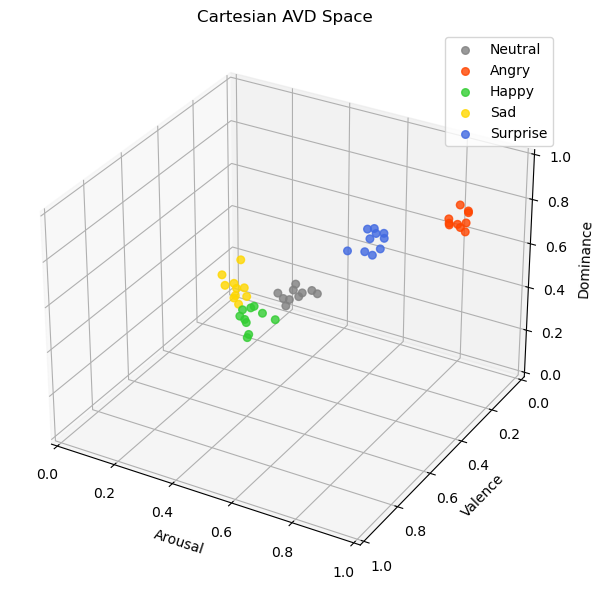

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 示例数据
base_avd = {
    'Neutral': [0.5, 0.5, 0.5],
    'Angry': [0.9, 0.2, 0.8],
    'Happy': [0.6, 0.9, 0.7],
    'Sad': [0.2, 0.3, 0.3],
    'Surprise': [0.8, 0.6, 0.9],
}
colors = {
    'Neutral': 'gray',
    'Angry': 'orangered',
    'Happy': 'limegreen',
    'Sad': 'gold',
    'Surprise': 'royalblue',
}

# 生成点数据
points = []
labels = []
for emotion, center in base_avd.items():
    for _ in range(10):  # 每类10个点
        pt = np.clip(np.random.normal(loc=center, scale=0.03, size=3), 0, 1)
        points.append(pt)
        labels.append(emotion)

avd_tensor = torch.tensor(points)

# 绘图
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

for emotion in base_avd:
    idx = [i for i, l in enumerate(labels) if l == emotion]
    ax.scatter(avd_tensor[idx, 0],  # Arousal
               avd_tensor[idx, 1],  # Valence
               avd_tensor[idx, 2],  # Dominance
               label=emotion,
               color=colors[emotion],
               s=30,
               alpha=0.8)

ax.set_title("Cartesian AVD Space")
ax.set_xlabel("Arousal")
ax.set_ylabel("Valence")
ax.set_zlabel("Dominance")

ax.set_xlim(0, 1)
ax.set_ylim(1, 0)  # 修正方向：valence 增加向右
ax.set_zlim(0, 1)

ax.legend()
plt.tight_layout()
# plt.savefig("avd_cartesian.png", dpi=150)
# print("[✓] Saved to avd_cartesian.png")
